In [2]:
import sys
sys.path.append("../src")
from pprint import pprint
from pathlib import Path

# Using GPT-4 to extract available data in semi-structured ecological datasets from Dryad

## Proposed abstract by bullet points
* Need for biodiversity data for global monitoring.
* Standardized data is needed to generate global biodiversity indicators.
* Many datasets are available through open data repositories such as Dryad
* These datasets are from various survey and protocols and contains a high diversity of data structures for different types of ecological study.
* To assess the effort needed to standardize these datasets, we need to know what type of data they contain.
* Large language models such as GPT-4 can help us generate descriptions of datasets by providing structured information about them.
* We can use a list of classification keywords to generate descriptions of datasets and provide an estimate of the confidence of its classification.
* We also compare the generated keywords with the keywords provided by Dryad to see if they overlap.
* Finally, we provide a list of datasets that can be used for biodiversity research organized by type of data.

## Abstract (generated by GPT-4)

To address the urgent need for global biodiversity monitoring, it is imperative to have access to comprehensive biodiversity data. This paper underscores the significance of standardized data in generating reliable global biodiversity indicators. While an array of datasets is readily available through open data repositories like Dryad, they emanate from varied surveys and protocols, leading to a vast diversity of data structures tailored for distinct ecological studies. One of the pressing challenges is understanding the type of data these repositories contain, which would further determine the extent of standardization required. Leveraging advanced tools like GPT-4, we can obtain structured descriptions of these datasets. By employing a predetermined list of classification keywords, this study not only generates descriptions for datasets but also provides a confidence estimate regarding its classification. A comparative analysis is then undertaken to ascertain the overlap between the generated keywords and those offered by Dryad. Conclusively, this paper presents a curated list of datasets, delineated based on their data type, thereby serving as a robust resource for biodiversity research.

## Methodology

* Gather abstracts for datasets from Dryad
  * Methodology : How to fetch abstracts from Dryad API ?
  * Preliminary analysis : What keywords allows to fetch datasets related to biodiversity and ecology data ?
  * Preliminary : What information is available from the Dryad API?
  * Analysis : How many datasets were available and what are the main characteristics of these datasets ?

* Describe the abstracts using GPT-4
  * Methodology : Workflow of classification using GPT-4, returning a structured output ?
  * Methodologies : Proposed strategies toward classification : 
  * Preliminary : Effect of the prompt on the output ? Quality of the json structure ?
    * Reference : Deterministic prompts for GPT-3 : https://arxiv.org/pdf/2104.08691.pdf
  * Analysis : Evaluating the precision of the classification 

## Description of datasets

The datasets explored in the current study and their attributes were obtained through Dryad web API using the keywords keywords "Quebec" and "Ecology".

For datasets made available, DryadAPI returns a JSON object with descriptive information about the dataset. Among the information returned, we are interested in the following attributes: authors with affiliation and contact, title, abstract, methods, usageNotes, keywords and license.

In our initial analysis, we commenced by evaluating fundamental statistics pertaining to the datasets. This encompassed examining the total count of datasets that were scrutinized, determining the mean dataset size, ascertaining the distribution of datasets across various ecological study categories, and analyzing the geographical spread of the data sources.

## Observations and limitations

* Generating a list of initial datasets : Searching for specific species in Quebec (Rangifer tarandus) returned a dataset (doi:10.5061/dryad.n726pq6) that was not made available through the query "Quebec" and "Ecology". Further investigation is needed to identify keywords for querying datasets.
  * [ ] Explore keywords for querying datasets
* Generating a json from gpt-4 output : The json generated by GPT-4 is not always valid. Output needs to be validated before being used.
  * [ ] Validate json output from GPT-4
* Categories classification confidence : The confidence seems to be variable. We need to explore repetitions of the same dataset to see if the confidence is consistent.
  * [ ] Explore confidence variability
  * [ ] Sample 10 datasets and generate 10 classifications for each dataset
  * [ ] For all categories, plot the distribution of confidence
  * [ ] See if this distribution is consistent across datasets
  * [ ] See if this distribution is consistent across ranges of confidence
* Usage of OpenAPI and costs : Openai API usage is tracked by the number of tokens used. For a single call, we use about 500 tokens. We need to explore the cost of using the API for our project.
  * [ ] Explore OpenAI API results, how many tokens are used per call, how many calls are needed for our project, how much does it cost ?
* Openai API returned structured json : The exact structure of the json returned by the API is highly variable. For us to be able to aggregate the results, the structure must be consistent. To do so, we need to explore the effect of the prompt on the structure of the json.
  * [ ] Explore the effect of the prompt on the structure of the json
* OpenAI API returned structured json : Categories are sometimes returned with variable orthography. 
  * [ ] Fix that, either through a post-processing step or by modifying the prompt
* Interfacing openai api : For data and study management, it would be useful to have a single repository containing results from the api, hopefully with original prompt, when was it run and the tokens used.
  * [ ] Refactor extract results as such.

In [3]:
from dryad_api import search_datasets
import pickle
from pathlib import Path

datasets_pickle = "data/datasets.pickle"

if Path(datasets_pickle).exists():
    with open(datasets_pickle, "rb") as f:
        datasets = pickle.load(f)
else:
    datasets = search_datasets(["quebec ecology"], per_page=100)
    with open(datasets_pickle, "wb") as f:
        pickle.dump(datasets, f)

In [4]:
# Show the first dataset authors, title, abstract, keyw
from pprint import pprint

pprint('Title :')
pprint(datasets[0].get("title", ""))

print('Authors :')
pprint(datasets[0].get("authors", []))

# List available keys ignoring the ones that start with an underscore
print('Available info :')
pprint(", ".join([k for k in datasets[0].keys() if not k.startswith("_")]))

'Title :'
('Thermal stratification and fish thermal preference explain vertical eDNA '
 'distributions in lakes')
Authors :
[{'affiliation': 'Queen Mary University of London',
  'affiliationROR': 'https://ror.org/026zzn846',
  'email': 'j.e.littlefair@qmul.ac.uk',
  'firstName': 'Joanne',
  'lastName': 'Littlefair',
  'orcid': '0000-0002-4481-0211'},
 {'affiliation': 'International Institute for Sustainable Development',
  'affiliationROR': 'https://ror.org/043zcks33',
  'email': 'lhrenchuk@iisd-ela.org',
  'firstName': 'Lee',
  'lastName': 'Hrenchuk',
  'orcid': '0000-0002-6194-094X'},
 {'affiliation': 'Fisheries and Oceans Canada',
  'affiliationROR': 'https://ror.org/02qa1x782',
  'email': 'Paul.Blanchfield@dfo-mpo.gc.ca',
  'firstName': 'Paul',
  'lastName': 'Blanchfield',
  'orcid': '0000-0003-0886-5642'},
 {'affiliation': 'Lakehead University',
  'affiliationROR': 'https://ror.org/023p7mg82',
  'email': 'mrennie@lakeheadu.ca',
  'firstName': 'Michael',
  'lastName': 'Rennie'},
 {

In [9]:
len(datasets)

50

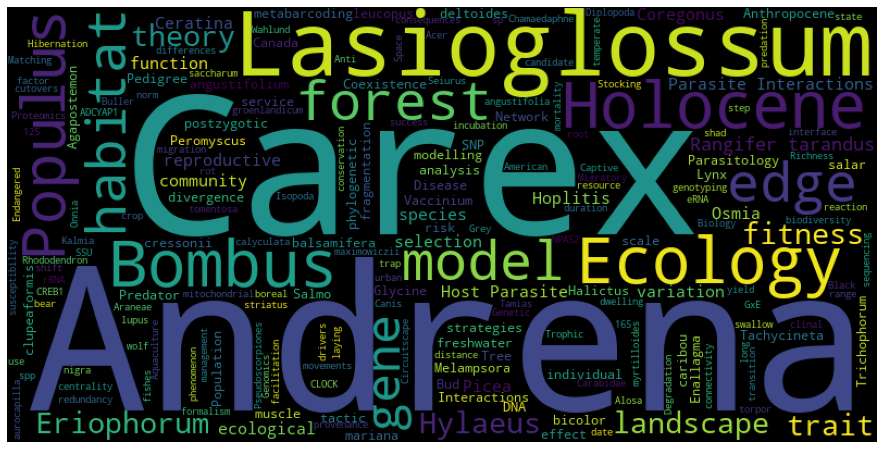

In [4]:
# Wordcloud of keywords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

keywords = []
for dataset in datasets:
    keywords.extend(dataset.get("keywords", []))


wordcloud = WordCloud(width=800, height=400).generate(" ".join(keywords))
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


In [5]:
# Display the number of datasets per license
from collections import Counter

licenses = Counter([dataset.get("license", "None") for dataset in datasets])
pprint(dict(licenses))

{'https://creativecommons.org/publicdomain/zero/1.0/': 50}


c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.

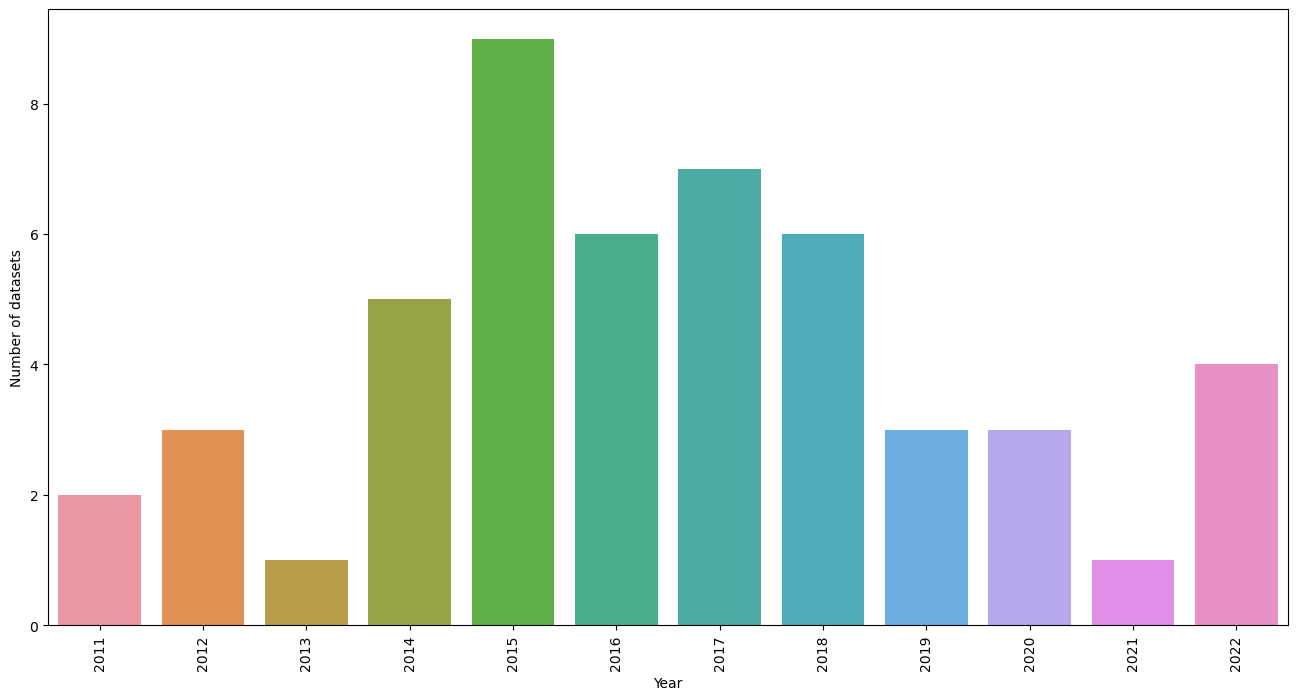

In [6]:
# Diagram of the number of dataset per year using seaborn
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

dates = [dataset.get("publicationDate", "") for dataset in datasets]
years = Counter([date.split("-")[0] for date in dates])
# Sort the years
years = dict(sorted(years.items(), key=lambda x: x[0]))

plt.figure(figsize=(16, 8))
sns.barplot(x=list(years.keys()), y=list(years.values()))
plt.xticks(rotation=90)
plt.xlabel("Year")
plt.ylabel("Number of datasets")

plt.show()

## Classification of the abstracts using OpenAI api


### Classification results of a single article


In [7]:
# Article of interest
doi = "doi:10.5061/dryad.n726pq6"
from dryad_api import get_dataset
dataset = get_dataset(doi)

# Show the authors, title, abstract, keywords, usageNotes
pprint('Title :')
pprint(dataset.get("title", ""))
print('Authors :')
pprint(dataset.get("authors", []))
print('Abstract :')
pprint(dataset.get("abstract", ""))
print('Keywords :')
pprint(dataset.get("keywords", []))
print('Usage notes :')
pprint(dataset.get("usageNotes", ""))

'Title :'
('Data from: Compensatory conservation measures for an endangered caribou '
 'population under climate change')
Authors :
[{'affiliation': 'Université Laval',
  'affiliationROR': 'https://ror.org/04sjchr03',
  'firstName': 'Sarah',
  'lastName': 'Bauduin'},
 {'affiliation': 'Université Laval',
  'affiliationROR': 'https://ror.org/04sjchr03',
  'firstName': 'Eliot',
  'lastName': 'McIntire'},
 {'affiliation': 'Center for Northern Studies',
  'affiliationROR': 'https://ror.org/01q8ytn75',
  'firstName': 'Martin-Hughes',
  'lastName': 'St-Laurent'},
 {'affiliation': 'Université Laval',
  'affiliationROR': 'https://ror.org/04sjchr03',
  'firstName': 'Steven G.',
  'lastName': 'Cumming'}]
Abstract :
('Future human land use and climate change may disrupt movement behaviors of '
 'terrestrial animals, thereby altering the ability of individuals to move '
 'across a landscape. Some of the expected changes result from processes whose '
 'effects will be difficult to alter, such as glo

In [8]:
# Classify the dataset abstract using the OpenAI API
from dotenv import load_dotenv
from gpt_extract import extract_from_text
dotenv_path = '.env'
load_dotenv(dotenv_path)

dataset_desc = extract_from_text(dataset.get("abstract", ""))
pprint(dataset_desc['response'])


{'additional_data': ['Spatially explicit individual-based movement model',
                     'Landscape scenarios'],
 'additional_keywords': ['Climate Change',
                         'Conservation Measures',
                         'Movement Behaviors',
                         'Landscape Scenarios',
                         'Road Restoration'],
 'categories': {'abundances': 0.6,
                'population time-series': 0.8,
                'trait data': 0.7},
 'dataset_year_end': None,
 'dataset_year_start': None,
 'regions_of_interest': ['Québec, Canada'],
 'taxonomic_groups': ['Caribou']}


## Classifyng all datasets

In [11]:
import time

prompt = """
You are EcodataGPT. From an open data abstract, you will return a json containing classifiers as keys to describe the data contained. Return an object with `categories` as keys associated with a confidence score as value. Also list all concerned `taxonomic_groups`. Also, list all `additional_keywords`you deem relevant to capture the type of data contained. Also, list `additional_data` used in relation to the ecological dataset. Also, return integers for `dataset_year_start`and `dataset_year_end` when available only and list `regions_of_interest`. Return only json of structured output.
"""

# Run the classification on all the datasets
classify_results_pickle = "data/classify_results.pickle"

classify_results = {}

if Path(classify_results_pickle).exists():
    with open(classify_results_pickle, "rb") as f:
        classify_results = pickle.load(f)

for i, dataset in enumerate(datasets):
    tic = time.time()
    print(f"Dataset {i+1}/{len(datasets)}")
    doi = dataset.get("identifier", "")
    abstract = dataset.get("abstract", "")

    if doi in classify_results:
        print("Already classified")
        continue
    
    result = None
    result_count = 0
    while not result or result_count < 5:
        result = extract_from_text(abstract, prompt=prompt)
        result_count += 1
    classify_results.update({doi: result['response']})
    with open(classify_results_pickle, "wb") as f:
        pickle.dump(classify_results, f)
    print(f"ellapsed time: {time.time() - tic:.2f}s")

Dataset 1/50
Already classified
Dataset 2/50
Already classified
Dataset 3/50
Already classified
Dataset 4/50
Already classified
Dataset 5/50
Already classified
Dataset 6/50
Already classified
Dataset 7/50
Already classified
Dataset 8/50
Already classified
Dataset 9/50
Already classified
Dataset 10/50
Already classified
Dataset 11/50
Already classified
Dataset 12/50
Already classified
Dataset 13/50
Already classified
Dataset 14/50
Already classified
Dataset 15/50
Already classified
Dataset 16/50
Already classified
Dataset 17/50
Already classified
Dataset 18/50
Already classified
Dataset 19/50
Already classified
Dataset 20/50
Already classified
Dataset 21/50
Already classified
Dataset 22/50
Already classified
Dataset 23/50
Already classified
Dataset 24/50
Already classified
Dataset 25/50
Already classified
Dataset 26/50
Already classified
Dataset 27/50
Already classified
Dataset 28/50
Already classified
Dataset 29/50
Already classified
Dataset 30/50
Already classified
Dataset 31/50
Alrea

In [22]:
# Assert that all the datasets have been correctly classified and store in
# classify_issue attribute
for result in classify_results.values():
    if result:
        try:
            assert "categories" in result
            assert isinstance(result["categories"], dict)
            result.update({"classify_issue": None})
        except AssertionError:
            result.update({"classify_issue": "categories not found or not a dict"})

# Count the number of datasets with classification issues
classify_issues = Counter([result.get("classify_issue", "None") for result in classify_results.values()])
pprint(dict(classify_issues))

# Save the classification results
classify_results_pickle = "data/classify_results.pickle"

with open(classify_results_pickle, "wb") as f:
    pickle.dump(classify_results, f)

{None: 48, 'categories not found or not a dict': 2}


In [25]:
# For each category, we want to know the number of datasets with confidence score > 0.9, between 0.7 and 0.9, between 0.5 and 0.7, between 0.3 and 0.5, between 0.1 and 0.3, and < 0.1
# The results are displayed in an vertical barplot using seaborn

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Get the categories
categories = set()
for result in classify_results.values():
    if result and not result.get("classify_issue"):
        categories |= {k.lower() for k in result.get("categories", {}).keys()}



In [26]:
# Get the confidence scores for each category
confidence_scores = {category: [] for category in categories}
for result in classify_results.values():
    if result and not result.get("classify_issue"):
        for category in confidence_scores.keys():
            confidence_scores[category].append(result.get("categories", {}).get(category, 0))



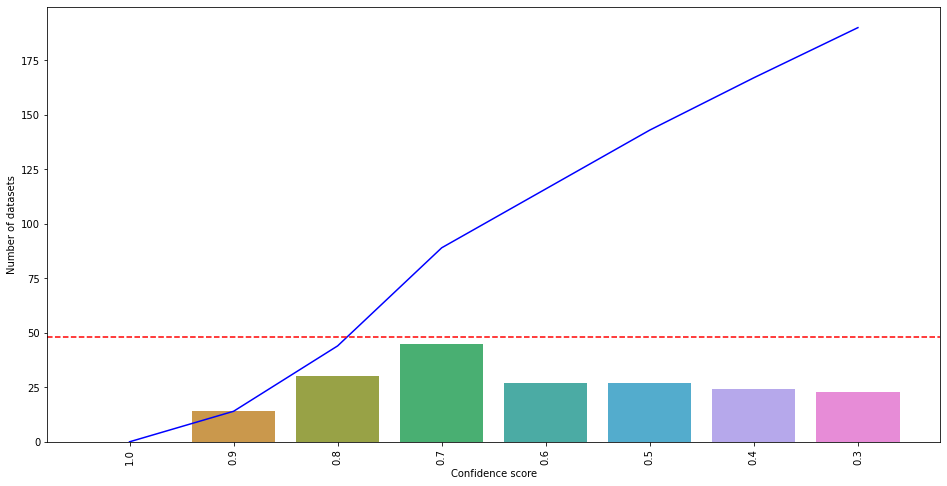

In [44]:
# Bar plot of confidence scores with bins for number of datasets above
# a certain confidence score

bins = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Counts for each bin
counts = {bin: 0 for bin in bins}
for category, scores in confidence_scores.items():
    for i, bin in enumerate(bins[:-1]):
        counts[bin] += len([score for score in scores if score >= bin and score < bins[i+1]])

# Add the cumulative counts as barplot
cumcounts = {bin: 0 for bin in bins}
for category, scores in confidence_scores.items():
    for i, bin in enumerate(bins[:-1]):
        cumcounts[bin] += len([score for score in scores if score >= bin])

# Make a df for seaborn
import pandas as pd
df = pd.DataFrame.from_dict(counts, orient="index", columns=["counts"])
# Flip rows vertically
df = df.iloc[::-1]

df["cumcounts"] = df["counts"].cumsum()
df = df.reset_index().rename(columns={"index": "confidence_score"})
df["confidence_score"] = df["confidence_score"].astype(str)

# Plot the barplot
plt.figure(figsize=(16, 8))
sns.barplot(x="confidence_score", y="counts", data=df)
sns.lineplot(x="confidence_score", y="cumcounts", data=df, color="blue")
plt.xticks(rotation=90)

# Plot horizontal line at the totalt number of datasets
n_ds= len([result for result in classify_results.values() if result and not result.get("classify_issue")])
plt.axhline(y=n_ds, color="red", linestyle="--")

plt.xlabel("Confidence score")
plt.ylabel("Number of datasets")
plt.show()


In [46]:
# Number of datasets with confidence score > 0.8 in dict for each category
confidence_scores_08 = {category: [] for category in categories}
for result in classify_results.values():
    if result and not result.get("classify_issue"):
        for category in confidence_scores_08.keys():
            if result.get("categories", {}).get(category, 0) >= 0.8:
                confidence_scores_08[category].append(result)
pprint({k: len(v) for k, v in confidence_scores_08.items() if v})

{'abundances': 5,
 'plots': 3,
 'population time-series': 16,
 'population_time_series': 3,
 'presence/absence': 4,
 'specimens': 2,
 'taxonomic abundance': 1,
 'trait data': 8,
 'trait_data': 1,
 'trajectory': 3}


In [56]:
# Return a df of the datasets with list of categories above 0.8
import pandas as pd
columns = ["doi", "first_author", "publication_year", "title", "categories", "taxonomic_groups", "regions_of_interest"]
df = pd.DataFrame(columns=columns)
df = df.set_index("doi")

for ds in datasets:
    doi = ds.get("identifier", "")
    first_author = ds.get("authors", [{}])[0].get("name", "")
    publication_year = ds.get("publicationDate", "").split("-")[0]
    title = ds.get("title", "")
    categories = []
    taxonomic_groups = []
    regions_of_interest = []
    if doi in classify_results:
        result = classify_results[doi]
        if result and not result.get("classify_issue"):
            categories = ", ".join([k for k, v in result.get("categories", {}).items() if v >= 0.8])
            taxonomic_groups = result.get("taxonomic_groups", [])
            regions_of_interest = result.get("regions_of_interest", [])
    else:
        continue
    df.loc[doi] = [first_author, publication_year, title, categories, taxonomic_groups, regions_of_interest]

# Show the df
df

,first_author,publication_year,title,categories,taxonomic_groups,regions_of_interest
doi,,,,,,
doi:10.5061/dryad.000000022,,2020,Thermal stratification and fish thermal prefer...,"fish eDNA depth profiles, taxonomic abundance","[warm-water fishes, cool-water fishes, Salveli...",[lake ecosystems]
doi:10.5061/dryad.pg4f4qrs4,,2022,Environmental nucleic acids: a field-based com...,,"[eDNA, eRNA]",[field-based setting]
doi:10.5061/dryad.4767v,,2016,Data from: Ecological gradients driving the di...,Plots,[Ericaceae],[Boreal Quebec]
doi:10.5061/dryad.np5hqbzvd,,2022,Neutral and adaptive drivers of genomic change...,,[Salvelinus fontinalis],[Western Canada]
doi:10.5061/dryad.6vk6f,,2015,Data from: Fitness dynamics within a poplar hy...,"population time-series, trait data, abundances...","[Populus balsamifera, P. deltoides spp. deltoi...","[eastern Canada, Quebec City, QC]"
doi:10.5061/dryad.63fr7,,2015,Data from: Fitness dynamics within a poplar hy...,"population time-series, trait data, abundances...","[Populus L., Populus balsamifera L.., P. delto...",[]
doi:10.5061/dryad.7tn01,,2018,Data from: Trait-matching and phylogeny as pre...,"Trait Data, Presence/Absence, Specimens",[Ground Beetles],[Global]
doi:10.5061/dryad.vs671,,2017,Data from: Individual variation in energy-savi...,[],[],[]
doi:10.5061/dryad.5ff8m0q,,2018,Data from: Structural and compositional mismat...,population_time_series,"[Enterobacteriaceae, Clostridiacea, Lactobacil...","[Quebec, Canada, Rimouski, Malbaie]"
